# Message Framing — an A/B experiment with randomization

**The study.** A between-subjects survey experiment: respondents are randomly assigned to read one of two texts (a statistics frame or a personal story) and then answer the same outcome questions. The design needs random assignment at the start, a text that only the assigned arm sees, counterbalanced outcome order, a timed manipulation check, an attention check, and a debrief.

**This directory:** `survey.py` (codebook, scripts, instrument, `options`), `analysis.py` (exclusions, balance checks, effects, report). The notebook imports them.

> In the cookbook this instrument was driven end to end in headless Chromium: both arms occurred, only the assigned vignette was visible, and `condition`, the `onSubmit` stamps and `__timers__` were stored with each response.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))          # make the study modules importable from any launcher

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

import siamang as sg
from siamang.reporting.tables import CrossTable, FreqTable, GroupMeanTable
from siamang.core import ContentPage

# Jupyter renders SurveyTable objects as HTML; make the text/plain fallback (text-only viewers,
# nbconvert --to script) show the Markdown table with its statistics footer instead of the dataclass repr.
for _cls in (FreqTable, CrossTable, GroupMeanTable):
    get_ipython().display_formatter.formatters["text/plain"].for_type(_cls, lambda t, p, cycle: p.text(t.to_markdown()))
OUT = Path("out"); OUT.mkdir(exist_ok=True)
print("siamang", sg.__version__, "| working directory:", Path.cwd().name)

siamang 0.6.0 | working directory: framing_experiment


## 1. The instrument: survey.py

Why the vignette gate is a plain string: `validate()` resolves typed expressions and `{name}` tokens against the variables bound to *questions*. `condition` is bound to none (an `onInit` script sets it), so `show_if=condition.eq(1)` fails; a brace-less `"condition = 1"` is passed through and the runtime re-evaluates page visibility when the script writes the answer. `utils.shuffle([1, 2])[0]` picks one arm (`utils.sample` returns an array).

In [2]:
print(Path("survey.py").read_text())

"""Message Framing Experiment — a between-subjects A/B survey experiment."""

import siamang as sg
from siamang.core import ContentPage, DisqualificationPage, FinalPage

AGREE7 = {1: "Strongly disagree", 2: "Disagree", 3: "Somewhat disagree", 4: "Neither",
          5: "Somewhat agree", 6: "Agree", 7: "Strongly agree"}

# ── Codebook ─────────────────────────────────────────────────────────────────
condition = sg.Variable("condition", scale="nominal", label="Experimental condition",
                        labels={1: "Control (statistics frame)", 2: "Treatment (story frame)"},
                        role="grouping")
age = sg.Variable("age", scale="ratio", label="Age", dtype="int", valid_range=(18, 99))
gender = sg.Variable("gender", scale="nominal", label="Gender",
                     labels={1: "Woman", 2: "Man", 3: "Other"})
politics = sg.Variable("politics", scale="ordinal", label="Political orientation (1 left - 7 right)",
                       labels={i: str(i) for i in range(1

In [3]:
from survey import condition, options, support, survey, variables

print("strict lint (a warning only — condition is filled by the onInit script):",
      [f"{w.severity}:{w.code}({w.location})" for w in survey.lint(level="strict")])
try:                                                                    # demonstration
    sg.Questionnaire(title="typed gate", variables=variables, pages=survey.pages[:2] + [
        ContentPage("v", body="x", show_if=condition.eq(1))]).validate()
except ValueError as e:
    print("EXPECTED (demonstration) — a typed gate on the script-set variable is rejected:", e)

strict lint (a warning only — condition is filled by the onInit script): ['warning:UNUSED_VARIABLE(condition)']
EXPECTED (demonstration) — a typed gate on the script-set variable is rejected: Page 'v' show_if references unknown variables: condition


In [4]:
# The UNUSED_VARIABLE warning is expected; exit code 0 = valid
!PYTHONPATH=. siamang validate survey.py --strict; echo "exit code: $?   (0 = valid)"

[warning] [UNUSED_VARIABLE] Variable 'condition' is registered but not used in questionnaire. (condition)


exit code: 0   (0 = valid)


## 2. Local deployment: one submission per arm

In [5]:
result = survey.deploy(backend_kwargs={"path": str(OUT / "framing.db")}, frontend_kwargs={"host": "127.0.0.1"}, **options)
for arm, sup in ((1, 4), (2, 6)):
    answers = {"condition": arm, "age": 31, "gender": 2, "politics": 4, "issue": 1, "support": sup, "donate": 40,
               "attention": 3, "manip_check": 5, "study": "framing-2026", "submitted_client_time": 1788376764216,
               "__options__": {}, "__pages__": [], "__errors__": {}, "__timers__": {"manip_check": 45}}
    print(requests.post(f"{result.url}/responses", json={"survey_id": result.survey_id, "responses": answers}, timeout=5).json())
raw = result.collect(); result.frontend_ref.stop()
raw.loc[:, ~raw.columns.str.startswith("__")]

{'ok': True, 'response_id': 1}
{'ok': True, 'response_id': 2}


,condition,age,gender,politics,issue,support,donate,attention,manip_check,study,submitted_client_time,_response_id,_submitted_at
0,1,31,2,4,1,4,40,3,5,framing-2026,1788376764216,1,2026-09-03 01:50:55
1,2,31,2,4,1,6,40,3,5,framing-2026,1788376764216,2,2026-09-03 01:50:55


## 3. Rehearsal data and the analysis step by step

`simulate()` yields no `condition` column and treats string gates as always true → assign the arm in pandas. `data.report.means()` picks Mann–Whitney for the ordinal `support` and a t-test for the ratio-scaled `donate` because there are two groups.

In [6]:
print(Path("analysis.py").read_text())

"""Message Framing Experiment — balance checks, treatment effects, report."""

from pathlib import Path

import numpy as np
import pandas as pd

import siamang as sg
from survey import survey

OUT = Path("out")
OUT.mkdir(exist_ok=True)

# ── 1. Rehearsal data: simulate() runs no scripts, so assign the arm in pandas ─
data = survey.simulate(n=400, seed=11)
rng = np.random.default_rng(11)
frame = data.frame.assign(condition=rng.choice([1, 2], size=len(data.frame)))
# fake a small effect so the report has something to show
frame.loc[frame["condition"] == 2, "support"] = (
    frame.loc[frame["condition"] == 2, "support"].clip(upper=6) + 1)
data = data.with_frame(frame)
print(data.report.freq("condition").to_markdown())        # labels come from the registry

# ── 2. Exclusions: failed attention checks ────────────────────────────────────
n0 = len(data.frame)
data = data.with_frame(data.frame[data.frame["attention"] == 3].reset_index(drop=True))
print(f"attention check: kept {len(data.fram

In [7]:
data = survey.simulate(n=400, seed=11)
rng = np.random.default_rng(11)
frame = data.frame.assign(condition=rng.choice([1, 2], size=len(data.frame)))
frame.loc[frame["condition"] == 2, "support"] = frame.loc[frame["condition"] == 2, "support"].clip(upper=6) + 1
data = data.with_frame(frame)
n0 = len(data.frame)
data = data.with_frame(data.frame[data.frame["attention"] == 3].reset_index(drop=True))
print(f"attention check: kept {len(data.frame)} of {n0} (synthetic answers are uniform; real data keeps far more)")
data.report.freq("condition")

attention check: kept 103 of 400 (synthetic answers are uniform; real data keeps far more)

Value,Label,N,%,Cumulative %
1,Control (statistics frame),50,48.5,48.5
2,Treatment (story frame),53,51.5,100.0
,Total,103,100.0,100.0


In [8]:
data.report.crosstab('condition', 'gender', pct='row')      # balance

Experimental condition,Woman,Man,Other,Total
Control (statistics frame),30.0,42.0,28.0,50
Treatment (story frame),34.0,30.2,35.8,53
Total,33.0,37.0,33.0,103


In [9]:
data.report.means('support', by='condition')                # ordinal, 2 groups → Mann-Whitney U

Experimental condition,Mean,SD,Median,N
Control (statistics frame),4.060,2.123,4.5,50
Treatment (story frame),4.755,1.697,5.0,53


In [10]:
data.report.means('donate', by='condition')                 # ratio, 2 groups → t-test

Experimental condition,Mean,SD,Median,N
Control (statistics frame),49.640,29.792,47.5,50
Treatment (story frame),42.151,31.289,39.0,53


{'statistic': 1066.5, 'p_value': 0.08479996623693861, 'group_a': 1, 'group_b': 2}
arm 1: support 50.0% [36.1%, 63.9%]
arm 2: support 52.8% [39.4%, 66.3%]


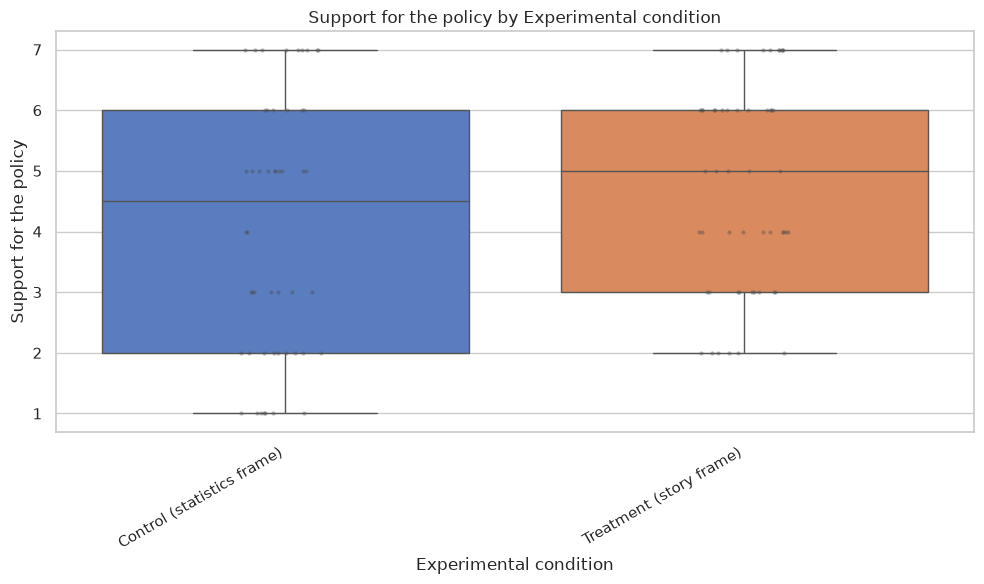

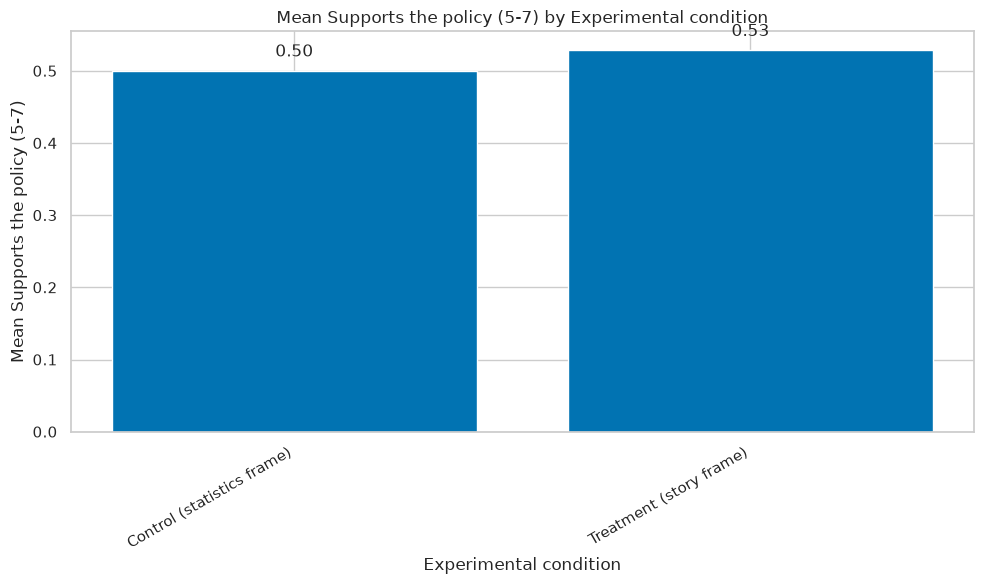

In [11]:
print(data.analysis.mannwhitney("support", "condition"))
data = data.derive(name="supports", expression=support.ge(5), label="Supports the policy (5-7)", labels={0: "No", 1: "Yes"})
for arm in (1, 2):
    ci = data.with_frame(data.frame[data.frame["condition"] == arm]).analysis.proportion_ci("supports", value=1)
    print(f"arm {arm}: support {ci['p']:.1%} [{ci['lower']:.1%}, {ci['upper']:.1%}]")
data.plot.boxplot("support", by="condition", show_points=True).plot(); plt.show()
data.plot.bar("supports", by="condition", palette="colorblind").plot(); plt.show()

## 4. The script version and the report

In [12]:
!PYTHONPATH=. python analysis.py 2>&1 | tail -2

Mann-Whitney U = 1098.5000; p = 0.1313; N = 103; Variable = The message focused on one person's story
['fig_5.png', 'framing.db', 'framing_report.md']


In [13]:
print(Path("out/framing_report.md").read_text()[:1200])

# Framing experiment — results

*Between-subjects, 2 arms*

## Design

**Analysed respondents:** 103

*Table 1. Balance: gender by arm*

| Experimental condition | Woman | Man | Other | Total |
|---|---|---|---|---|
| Control (statistics frame) | 15 | 21 | 14 | 50 |
| Treatment (story frame) | 18 | 16 | 19 | 53 |
| Total | 33 | 37 | 33 | 103 |

χ² = 1.6200; df = 2; p = 0.4449; Cramér's V = 0.1250; N = 103

## Effects

*Table 2. Policy support by arm*

| Experimental condition | Mean | SD | Median | N |
|---|---|---|---|---|
| Control (statistics frame) | 4.06 | 2.123 | 4.5 | 50 |
| Treatment (story frame) | 4.755 | 1.697 | 5.0 | 53 |

Mann-Whitney U = 1066.5000; p = 0.0848; N = 103; Variable = Support for the policy

![Figure 1. Support by arm](fig_5.png)

*Figure 1. Support by arm*

*Table 3. Share supporting the policy by arm*

| Experimental condition | No | Yes | Total |
|---|---|---|---|
| Control (statistics frame) | 50.0 | 50.0 | 50 |
| Treatment (story frame) | 47.2 | 52.8 | 53